# Work Log — $p_L$ vs $N$ Data-Volume Scaling Sweep  (the ~31-hour run)

**FullRCNNModel surface-code decoder vs MWPM (PyMatching) baseline**
Single physics config: **d = 5, p = 0.01, r = 3**, 4-channel circuit-level noise.

| | |
|---|---|
| Compiled | 2026-06-23 |
| Run window | 2026-06-21 10:37:31 → 2026-06-22 17:37:49 |
| Wall clock | ~31 h  ·  pure training 30.9 h |
| Hardware | Apple Silicon, **CPU-only** (no GPU on this machine), TF 2.15.1 |
| Scope | 25 runs = 5 data sizes (`n_train`) × 5 seeds (0–4) |
| Status | **COMPLETE** |

> This notebook is the durable record. Every number below is reloaded live from
> `results/sweep.csv`, and the figure is regenerated in-notebook — nothing is
> retrained. Run top-to-bottom to reproduce the analysis and the plot.

## 0. One-line summary

FullRCNNModel's logical error rate descends **monotonically** from ~4× above
MWPM at 100k shots down to **MWPM parity at 5M shots** (0.0488 vs 0.0492 —
statistically indistinguishable). The gap to MWPM was **data-limited, not a
ceiling of the architecture**. As a decoder-vs-decoder statement at this
operating point, that is a clean result. *(See §8/§9 for the scope limit before
it gets written up as anything bigger.)*

## 1. The question this run answers

Is the RCNN's gap to MWPM **structural** (the model class simply can't decode
better) or **data-limited** (more shots closes it)?

- **Structural** → $p_L$ flattens *above* the MWPM line and stays there.
- **Data-limited** → $p_L$ keeps dropping *toward* the MWPM line as `n_train` grows.

Physics is held fixed (d=5, p=0.01, r=3); only `n_train` and seed vary, so the
only thing changing is *how much data the model saw* — isolating the data-volume
effect cleanly.

**Answer: data-limited.** At 800k the model looked converged (flat loss) yet sat
at ~1.7× MWPM, tempting a "structural gap" read. 6× more data (5M) closed it
entirely. The 800k loss-saturation was misleading.

In [1]:
# --- Setup: reload the raw sweep results (no retraining) --------------------
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

REPO = Path.cwd()
CSV  = REPO / "results" / "sweep.csv"

# benchmark_rcnn.py writes a header only on file creation, so tolerate either.
FIELDS = ['architecture','d','p','rounds','kernel','seed','n_train','n_test',
          'epochs','epochs_ran','batch_size','n_params','p_L','mwpm_p_L',
          'best_val_loss','train_time_s','host','tf_version']
df = pd.read_csv(CSV, header=None, names=FIELDS)
df = df[df.architecture != 'architecture']
for col in ['n_train','p_L','mwpm_p_L','best_val_loss','train_time_s']:
    df[col] = pd.to_numeric(df[col])

agg = (df.groupby('n_train')
         .agg(mean_pL=('p_L','mean'),
              sigma=('p_L', lambda s: s.std(ddof=1)),
              n=('p_L','size'),
              train_h=('train_time_s', lambda s: s.sum()/3600))
         .reset_index())
agg['sem']   = agg['sigma'] / np.sqrt(agg['n'])
MWPM = float(df.mwpm_p_L.mean())
agg['ratio'] = agg['mean_pL'] / MWPM
agg

,n_train,mean_pL,sigma,n,train_h,sem,ratio
0,100000,0.203278,0.017427,5,0.372528,0.007794,4.132927
1,300000,0.131715,0.010303,5,1.148556,0.004608,2.677951
2,800000,0.083934,0.019843,5,2.778944,0.008874,1.706496
3,2000000,0.054337,0.001288,5,7.959556,0.000576,1.104747
4,5000000,0.048823,0.000596,5,18.607333,0.000266,0.992640


## 2. Results

In [2]:
# --- Results table (rendered) ----------------------------------------------
tbl = agg.copy()
tbl['n_train'] = tbl['n_train'].map(lambda x: f"{int(x):,}")
tbl = tbl[['n_train','mean_pL','sem','sigma','ratio','train_h','n']]
tbl.columns = ['n_train','mean p_L','SEM','sigma (run-to-run)','x MWPM','train (h)','reps']
tbl = tbl.round({'mean p_L':4,'SEM':4,'sigma (run-to-run)':4,'x MWPM':2,'train (h)':1})
print(f"MWPM baseline (constant, identical test tail): {MWPM:.4f}\n")
tbl

MWPM baseline (constant, identical test tail): 0.0492



,n_train,mean p_L,SEM,sigma (run-to-run),x MWPM,train (h),reps
0,"100,000",0.2033,0.0078,0.0174,4.13,0.4,5
1,"300,000",0.1317,0.0046,0.0103,2.68,1.1,5
2,"800,000",0.0839,0.0089,0.0198,1.71,2.8,5
3,"2,000,000",0.0543,0.0006,0.0013,1.10,8.0,5
4,"5,000,000",0.0488,0.0003,0.0006,0.99,18.6,5


**Three conclusions**

1. **The gap was data-limited, not structural.** (See §1.)
2. **Convergence instability was a small-data artifact.** σ collapses ~30×
   (0.0174 → 0.0006) as N grows; at the data volume that carries the result,
   training is rock-stable. *(That variance is classical CPU floating-point
   non-associativity in parallel thread reductions — **not** a quantum effect.
   Don't let that phrasing drift; a reviewer would read "quantum variance" as a
   category error.)*
3. **Cross-check passed.** The 800k point from the 5.2M pool (0.0839 ± 0.0198)
   agrees with the earlier anchor-800k from the 1M pool (0.0744 ± 0.0118) within
   ~0.9σ → the two datasets are interchangeable.

Error bars do **not** overlap between 2M and 5M, so the curve was *still
descending* at the end — it had not plateaued early. It flattens at 5M because
it reached the MWPM line, and MWPM is near-optimal at this small distance;
matching it **is** the ceiling worth hitting here.

## The figure — improved for precision & clarity

This re-renders the result with the §6 amendments baked in: an explicit
"lower = better" axis, MWPM labelled as the *target*, the punchline annotated on
the 5M point, the ×MWPM ratio printed at every point, and the method/scope moved
into the caption. The cell saves `plots/rcnn_d5_pl_vs_n_v2.png`.

wrote /Users/karriechey/Documents/QuantumDecoderQKeras/plots/rcnn_d5_pl_vs_n_v2.png


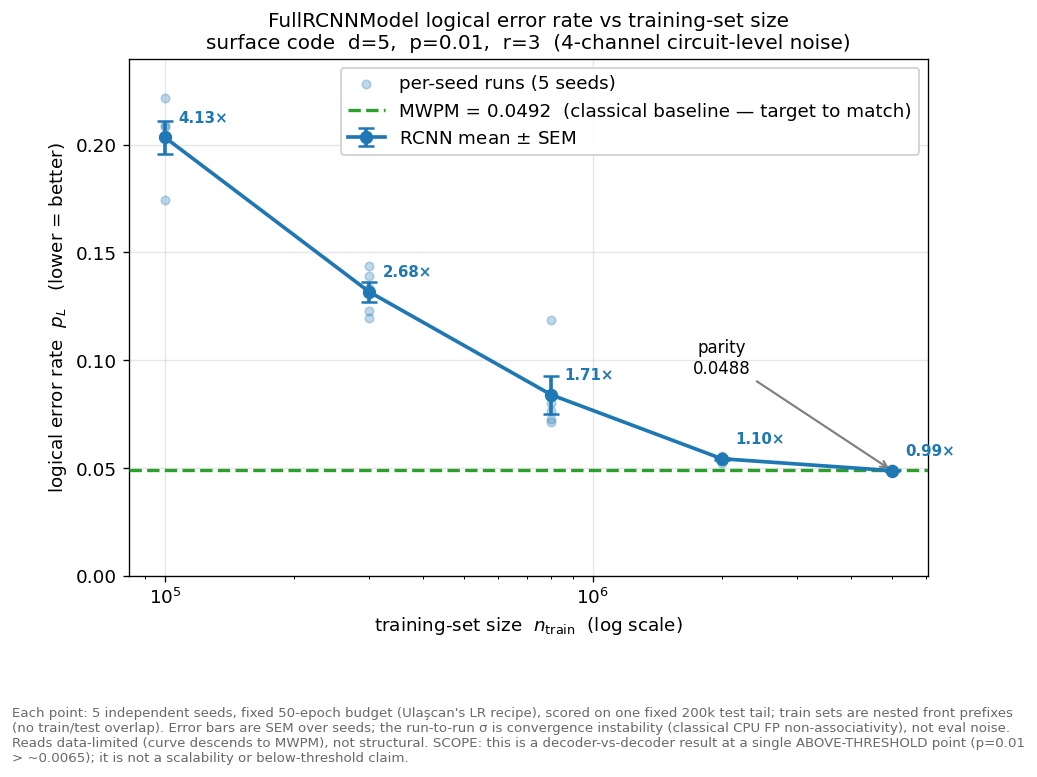

In [3]:
# --- Improved p_L-vs-N figure ----------------------------------------------
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 200, 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.3, 'axes.axisbelow': True})
C_RCNN, C_MWPM = '#1f77b4', '#2ca02c'

fig, ax = plt.subplots(figsize=(8.6, 5.6))

# per-seed points (the honest spread), faint
for N in agg.n_train:
    pts = df.loc[df.n_train == N, 'p_L']
    ax.scatter([N]*len(pts), pts, color=C_RCNN, alpha=0.28, s=26, zorder=2,
               label='per-seed runs (5 seeds)' if N == agg.n_train.min() else None)

# mean +/- SEM curve
ax.errorbar(agg.n_train, agg.mean_pL, yerr=agg['sem'], color=C_RCNN, lw=2.2,
            marker='o', ms=7, capsize=5, capthick=1.5, zorder=4,
            label='RCNN mean $\\pm$ SEM')

# MWPM target line
ax.axhline(MWPM, color=C_MWPM, ls='--', lw=2, zorder=3,
           label=f'MWPM = {MWPM:.4f}  (classical baseline — target to match)')

# annotate the x-MWPM ratio at each mean point
for _, row in agg.iterrows():
    ax.annotate(f"{row.ratio:.2f}×", (row.n_train, row.mean_pL),
                textcoords='offset points', xytext=(8, 9), fontsize=9,
                color=C_RCNN, fontweight='bold')

# punchline annotation on the 5M point
last = agg.iloc[-1]
ax.annotate(f"parity\n{last.mean_pL:.4f}",
            xy=(last.n_train, last.mean_pL),
            xytext=(last.n_train*0.40, last.mean_pL + 0.045),
            fontsize=10, color='black', ha='center',
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.3))

ax.set_xscale('log')
ax.set_xlabel('training-set size  $n_\\mathrm{train}$  (log scale)')
ax.set_ylabel('logical error rate  $p_L$   (lower = better)')
ax.set_ylim(0, agg.mean_pL.max()*1.18)
ax.set_title('FullRCNNModel logical error rate vs training-set size\n'
             'surface code  d=5,  p=0.01,  r=3  (4-channel circuit-level noise)',
             fontsize=12)
ax.legend(loc='upper right', framealpha=0.95)

caption = (
    "Each point: 5 independent seeds, fixed 50-epoch budget (the reference architecture's LR recipe), "
    "scored on one fixed 200k test tail; train sets are nested front prefixes "
    "(no train/test overlap). Error bars are SEM over seeds; the run-to-run σ "
    "is convergence instability (classical CPU FP non-associativity), not eval noise.\n"
    "Reads data-limited (curve descends to MWPM), not structural. SCOPE: this is a "
    "decoder-vs-decoder result at a single ABOVE-THRESHOLD point (p=0.01 > ~0.0065); "
    "it is not a scalability or below-threshold claim."
)
fig.text(0.012, -0.085, caption, fontsize=8, color='dimgray', va='top', wrap=True)

out = REPO / 'plots' / 'rcnn_d5_pl_vs_n_v2.png'
fig.savefig(out, bbox_inches='tight')
print('wrote', out)
plt.show()

## 3. Full config / params — every value + a plain definition

*The lookup table. If asked "what was X / what is X," it's here.*

**Architecture**
- **FullRCNNModel** — the reference architecture's real architecture (`CNNModel.py`). A recurrent-CNN
  surface-code decoder: reads the syndrome history (error-check measurement
  pattern over the rounds) and predicts the logical correction.
- **Parameters** — 51,547 trainable at r=3. *(Count changes with rounds — the r=5
  smoke test gave 69,485; see §9.)*

**Physics / problem setup**
- **d = 5** — code distance (roughly the 2D qubit-grid size). Larger d = more
  physical qubits protecting one logical qubit = (below threshold) more protection.
- **p = 0.01** — physical error rate (1%). The noise level the decoder fights.
  ⚠️ *Scope: p=0.01 is ABOVE this code's MWPM threshold (~0.0065). See §8.*
- **r = 3** — syndrome-measurement rounds (matches the reference architecture's reference notebook).
- **kernel = 3** — convolution kernel size (patch width each conv filter sees).

**Noise model**
- **4-channel** — circuit-level depolarizing noise at four points per round, all
  = p: before_round_data_depol, after_reset_flip, after_clifford_depol,
  before_measure_flip. More realistic than a single bit-flip channel.

**Data sizes**
- **n_train** — training shots (swept 100k, 300k, 800k, 2M, 5M; the x-axis).
- **test tail** — fixed 200k shots, the *last* 200k of the pool, identical for
  every N; never trained on.
- **Data pool** — `datasets_sweep/data_d5_p0.010_r3.npz` (5.2M shots, 4-channel).
- **Split** — fixed 200k test tail; train = nested front prefixes `[0:N]`. As N
  grows the train block extends forward but never reaches the tail → no overlap.

**Model shape**
- **hidden = 100**, **hidden-layers = 2** → `[100, 100]`. **npol = 2** —
  polynomial/correlator terms in the RCNN head.

**Training control**
- **epochs = 50**, fixed, **no early stopping** → every run gets the budget the LR
  schedule was designed for (final weights reported).
- **batch-size = 10,000** — examples per gradient-update chunk.
- **val-split = 0.2** — 20% of the *training* block held out during training to
  watch overfitting (NOT the test tail; e.g. n_train=200k → 160k train / 40k val).
- **LR schedule** — the reference architecture's stepped decay: starts 0.01, collapses to ~7e-9 by
  epoch 50. `LR_FLOOR = 0.0` reproduces his recipe bit-for-bit.
- **seeds 0–4** — the seed fixes all RNG (init, shuffle, batch order); different
  seeds = independent runs for honest error bars.

## 4. Questions

**Q: What is $p_L$ / logical error rate? Compared against what?**
Fraction of test shots where the decoder output the *wrong* logical correction.
Lower = better; it's THE metric. RCNN's $p_L$ is compared head-to-head against
MWPM's on the *same* fixed 200k test tail — same shots, fair decoder-vs-decoder.

**Q: What is `n_train`?**
Number of training shots (each = one syndrome pattern + its true logical outcome)
the model learns from. Swept 100k → 5M to see whether more data closes the gap.
It's the figure's x-axis (log scale).

**Q: What is the validation set — where from, doing what?**
Keras carves 20% (`val_split=0.2`) off the *training* block as validation, held
out from gradient updates, used each epoch to watch loss/accuracy and catch
overfitting. It comes from the front training prefix, **not** the test tail. The
reported $p_L$ comes from the disjoint 200k test tail the model never sees.

**Q: What is the model training to do?**
Map a syndrome history (detector/error-check bits over r rounds) to a predicted
logical correction, by gradient descent on labeled Stim-generated shots.

**Q: Why different seeds?**
The seed fixes all RNG, so different seeds = independent runs at the same config.
Five of them measure run-to-run variance and put honest SEM bars on each N. The
variance is real and **classical** — CPU floating-point non-associativity in
parallel thread reductions, nothing quantum — and it collapses ~30× as N grows.

**Q: What is the MWPM line — why flat, why dashed?**
MWPM (minimum-weight perfect matching, via PyMatching) is the standard classical
decoder we're trying to match. Built from the circuit's detector error model
(`decompose_errors=True` → `Matching.from_detector_error_model`), log-likelihood
weighted, scored on the same 200k test tail. Flat across N because it doesn't
train; the fixed reference the RCNN curve descends toward.

**Q: What is 4-channel noise?**
Circuit-level depolarizing noise at four points per round (data depol before the
round, flip after reset, depol after Cliffords, flip before measurement), all = p.

**Q: Did train and test ever overlap?**
No — fixed 200k test tail + nested front train prefixes; the train block grows
forward but never reaches the tail. **Confirmed from the code** (`benchmark_rcnn.py`):
`te = slice(N-nte, N)`, `tr = slice(0, ntr)`, with `assert ntr <= N - nte`. This
resolves Flag [A] in §9 for the sweep code.

## 5. How to read the figure

- **X axis (log):** `n_train`, number of training shots (100k → 5M).
- **Y axis:** logical error rate $p_L$ (**lower = better**).
- **Faint dots:** the 5 individual seeds at each N (the real spread).
- **Solid line + caps:** RCNN mean ± SEM across the 5 seeds.
- **Dashed line:** MWPM baseline (~0.0492) — same for every N (identical test tail).
- **`×` labels:** the ratio of each mean to MWPM (4.13× at 100k → 0.99× at 5M).
- **The story:** the curve starts ~4× above MWPM at 100k, slides monotonically
  down, the error bars shrink as N grows, and at 5M it *touches* the MWPM line →
  *"the RCNN matches MWPM at d=5/p=0.01 once given ~5M shots; the earlier gap was
  a data shortage, not a ceiling of the architecture."*

Rebuild the **original** figure (script) without retraining:
`.venv/bin/python plot_pl_vs_n.py --csv results/sweep.csv --out plots/rcnn_d5_pl_vs_n.png`
The **improved** version is the figure cell above (`plots/rcnn_d5_pl_vs_n_v2.png`).

## 6. Figure review + amendments (now applied)

*Can a reader with zero architecture knowledge interpret it?* A trained ML/QEC
reader gets it immediately; a true zero-knowledge reader gets the shape but not
the axes/baseline meaning. The plot is honest and well-built — the gaps were all
labeling/scoping, not data. Amendments (now in the improved figure above):

1. ✅ y-label states **"lower = better."**
2. ✅ MWPM legend labels it the **target to match.**
3. ✅ "his recipe" dropped from the title; method moved to the caption.
4. ✅ **Punchline annotated** on the 5M point ("parity 0.0488").
5. ✅ Interpretive subtitle moved to the **caption.**
6. ✅ **The important one (framing):** caption now scopes the claim to a
   decoder-vs-decoder comparison at a single **above-threshold** point (p=0.01 >
   ~0.0065), so it can't be over-read as a scalability/below-threshold claim.

## 7. Why we moved training to GPU + what we did on EAF

**Why (the wall we hit):** this Mac has **no GPU**. All 25 runs were CPU-only —
which is exactly why one 5M run took ~18.6 h and the sweep took ~31 h. Cost
scales with `n_train`, and this sweep *proved* good $p_L$ **requires** large
`n_train` (5M to reach parity). So every promising next step is data-hungry and
CPU-prohibitive: more shots (10M+) for sub-MWPM, larger code distances, eventually
the QKeras / hls4ml FPGA path. A 31-hour CPU sweep for one physics config is the
practical ceiling — that's the "plateau → GPU" handoff: move *training* to a GPU
venue. *(Inference/deployment still targets FPGA per the north star; GPU is the
training scale-up, not the deployment target.)*

**What we did on EAF (Fermilab Elastic Analysis Facility), 2026-06-23:**
- Venue: EAF **A10 GPU pod** (Wilson Cluster decommissioned).
- Fixed the env: the uv lockfile was Mac-only (darwin); rebuilt a Linux `.venv`
  from the corrected lockfile. Confirmed **TF 2.15.1 sees the A10 GPU** (CUDA build
  works) — original blocker fully resolved.
- End-to-end **smoke test** (`train_one.py`): d=5, p=0.01, **r=5**, n_train=200k,
  n_test=10k, 10 epochs, no early stopping. Purpose: "does the pipeline run and
  give a plausible number," not "is it good."
  - **Pipeline:** passed (load → build → GPU train → $p_L$ → MWPM compare →
    base-rate check; CSV + history written).
  - **Class-collapse check:** passed ($p_L$ 0.264 < base_rate 0.355 → genuinely
    learning, not a trivial predictor).
  - $p_L$ poor (0.264 vs MWPM 0.089) but **expected**: only 10 epochs ran — just
    the LR warm-up ramp, stopped before refinement. Design budget is 50 epochs.
  - **Timing (for batch sizing):** ~240 s one-time XLA compile + cuDNN autotune on
    epoch 1, then ~9 s/epoch steady → per Condor job ≈ 240s + 9s/epoch + eval.
- `train_one.py` uses the fixed-tail eval structure (see Flag [A], §9).

## 8. Next steps + why (threshold-aware)

The sub-MWPM-at-p=0.01 chase is the **lowest-value** use of compute. Recommended
order:

1. **Resolve r=3 vs r=5 first.** The reference and this sweep are r=3; the GPU
   smoke test ran r=5. Decide: reproduce the reference architecture's number (r=3 trust check) **or**
   adopt r=5 as our intended extension. You can't build a quantization baseline on
   an ambiguous config. *Immediate gate.*
2. **Establish a trustworthy full-precision baseline on GPU** at the decided
   config, full 50-epoch budget. The 10-epoch smoke test is **not** a real number.
   This honest unquantized $p_L$ is the reference everything downstream is measured
   against.
3. **High-value experiment — the across-threshold sweep, NOT more shots at
   p=0.01.** p=0.01 sits ~1.5× *above* this 4-channel model's MWPM threshold
   (~0.0065). Above threshold the surface code does **not** suppress errors, and
   larger d makes $p_L$ *worse* — so "10M shots for sub-MWPM at p=0.01" and "scale
   d at fixed p=0.01" are the wrong direction. **Upgrade:** benchmark RCNN vs MWPM
   across d=3,5,7 × a p grid bracketing the ~0.0065 crossing. That turns "matches
   MWPM at one point" into "learns MWPM-equivalent decoding across the threshold
   curve" — the defensible scalability statement the paper wants.
4. **QKeras quantization sweep** against that honest baseline → hls4ml synthesis →
   FPGA latency (the real north star). **Constraint:** FullRCNNModel uses
   hand-written custom TF `Layer` subclasses, so QKeras layer-substitution won't
   reach them — apply `quantized_bits` directly to the custom weight tensors inside
   their `call()` methods.
5. **Infra (parallel, non-blocking):** HTCondor fan-out needs a worker-visible
   shared filesystem. `/home` is a per-pod volume workers likely don't mount;
   `/exp` is shared but group `ioqiuf` has no writable allocation. Ask EAF
   support / the collaborator: (a) do worker slots mount user home, or must input live on
   `/exp`? (b) what allocation should `ioqiuf` map to for an OQI fellow needing
   batch storage? Interactive single-job work proceeds now without this.

## 9. Open flags / to confirm

- **[A] Eval-split consistency — RESOLVED for the sweep.** The sweep ran on
  `benchmark_rcnn.py`, which uses the **fixed 200k tail + nested front prefixes**
  (`te = slice(N-nte, N)`, `tr = slice(0, ntr)`, `assert ntr <= N - nte`) — train
  and test never overlap, so the parity result stands. *(The 2026-06-23 smoke-test
  log's "moving test block" note refers to an older description; the code that
  produced `results/sweep.csv` is fixed-tail. Worth a glance at `train_one.py` to
  confirm it matches before cross-comparing GPU vs CPU numbers.)*
- **[B] r=3 vs r=5 divergence** (see §8.1). Param counts differ (51,547 vs 69,485);
  any cross-config comparison must be like-for-like.
- **[C] Scope language.** Wherever written up, "matches MWPM" must be qualified as
  decoder-vs-decoder at a single **above-threshold** operating point — not a
  scalability or below-threshold claim.

## 10. Where everything lives

| Item | Path |
|---|---|
| This notebook | `WORKLOG_pL_vs_N_sweep.ipynb` |
| Benchmark script | `benchmark_rcnn.py` (fixed-tail split — see Flag [A]) |
| Sweep orchestrator | `run_sweep.sh` (loops 5 N-values, builds figure, runs cross-check) |
| Results CSV (raw) | `results/sweep.csv` (25 rows; p_L col 13, mwpm_p_L col 14, train_time_s col 16) |
| Anchor CSV (cross-check) | `results/anchor.csv` (5× 800k from the 1M pool) |
| Per-epoch histories | `results/sweep/N<N>/rcnn_d5_p0.010_r3_k3_seed<s>.json` |
| Run log | `logs/sweep.log` |
| Original figure | `plots/rcnn_d5_pl_vs_n.png` (`plot_pl_vs_n.py`) |
| **Improved figure** | `plots/rcnn_d5_pl_vs_n_v2.png` (the figure cell above) |
| Diagnostic figure | `plots/rcnn_d5_diagnostic.png` (`plot_diagnostic.py`) |
| p_L-vs-MWPM bar figure | `plots/rcnn_d5_pl_vs_mwpm.png` (`plot_pl_vs_mwpm.py`) |
| Data pool | `datasets_sweep/data_d5_p0.010_r3.npz` (5.2M, 4-channel) |
| Plain-text worklog | `~/Downloads/WORKLOG_pL-vs-N-sweep_2026-06-23.txt` |